In [1]:
!pwd

/home/greystone/locchuong/ocr-exp


In [2]:
import os
import cv2
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from preprocess import Extractor
from circle_fit import taubinSVD

In [3]:
# instance of extractor
extractor = Extractor()
extractor.load_model()

# 1.extract roi

In [4]:
def rotateAndScale(img, scaleFactor = 0.5, degreesCCW = 30):
    '''
    rotate image with no cut out vertices
    Args:
        img: original image
        scaleFactor: scale of output image
        degreesCCW: angle (degrees)
    Return:
        rotateImg: rotated image
        M: rotate matrix
    '''
    h,w,c = img.shape #note: numpy uses (y,x) convention but most OpenCV functions use (x,y)
    M = cv2.getRotationMatrix2D(center=(w/2,h/2), angle=degreesCCW, scale=scaleFactor) #rotate about center of image.

    #choose a new image size.
    new_w,new_h = w*scaleFactor,h*scaleFactor
    #include this if you want to prevent corners being cut off
    r = np.deg2rad(degreesCCW)
    new_w,new_h = (abs(np.sin(r)*new_h) + abs(np.cos(r)*new_w),abs(np.sin(r)*new_w) + abs(np.cos(r)*new_h))

    #the warpAffine function call, below, basically works like this:
    # 1. apply the M transformation on each pixel of the original image
    # 2. save everything that falls within the upper-left "dsize" portion of the resulting image.

    #So I will find the translation that moves the result to the center of that region.
    (tx,ty) = ((new_w-w)/2,(new_h-h)/2)
    M[0,2] += tx #third column of matrix holds translation, which takes effect after rotation.
    M[1,2] += ty

    rotatedImg = cv2.warpAffine(img, M, dsize=(int(new_w),int(new_h)))
    return rotatedImg,M

In [5]:
def calc_dist(pt1,pt2):
    '''
    Calculate distance of 2 point
    Args:
        pt1: first point
        pt2: second point
    Return:
        dist: distance
    '''
    dist = cv2.norm(pt1-pt2)
    return dist

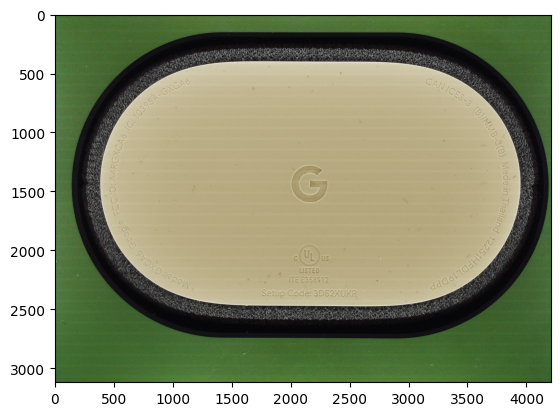

In [6]:
img_org = cv2.imread("samples/blue/blue_16.jpg") #"Google Nest Audio.jpg"
h,w,c=img_org.shape
if h>w:
    img_org = cv2.rotate(img_org,cv2.ROTATE_90_CLOCKWISE)
img = img_org.copy()
plt.imshow(img)

In [7]:
# extract mask
mask = extractor.get_mask(img)

/home/greystone/locchuong/ocr-exp/pre/pre_post_processing.py:115: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  xmin = np.clip(np.floor(box[:, 0].min()).astype(np.int), 0, w - 1)
/home/greystone/locchuong/ocr-exp/pre/pre_post_processing.py:116: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your curren

In [8]:
# find contours
contours, hierarchy = cv2.findContours(mask.astype("uint8"), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

In [9]:
# select suitable area
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)

In [10]:
# select suitable area
cnts = []
s_min = np.array(areas).mean()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > s_min:
        cnts.append(cnt)

(3104, 4192, 3)


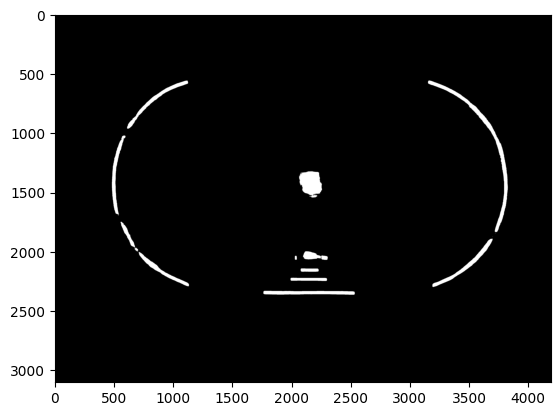

In [11]:
mask3 = cv2.merge([mask.astype("uint8"),mask.astype("uint8"),mask.astype("uint8")])
print(mask3.shape)
plt.imshow(mask3)

boxs 11


Text(0.5, 1.0, 'greater then mean rotated rectangle')

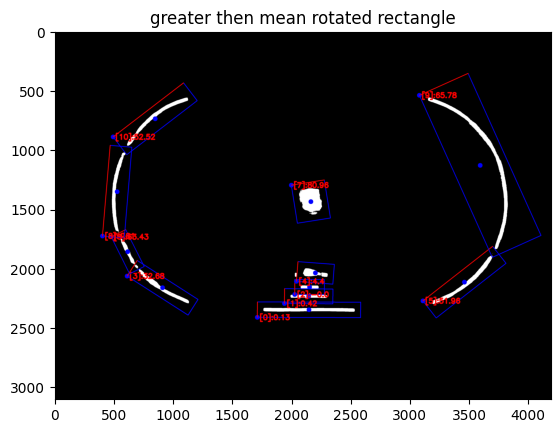

In [12]:
padding = 100
boxs = []
rects = []
angles = [] # degree
img = mask3.copy()
for i,cnt in enumerate(cnts):
    # roated rect (minimum rect)
    rect = cv2.minAreaRect(cnt)
    # angle
    angle = rect[-1]
    angles.append(angle)
    # new rect add padding
    h = int(rect[1][0]+ padding)
    w = int(rect[1][1]+ padding)
    new_rect = (rect[0],(h,w),angle) #h,w
    rects.append(new_rect)
    box = cv2.boxPoints(new_rect)
    box = np.int0(box)
    boxs.append(box)
    # draw
    cv2.drawContours(img,[box],0,(0,0,255),6) # min rect
    cv2.circle(img,(int(rect[0][0]),int(rect[0][1])),20,(0,0,255),-1)# top point
    cv2.circle(img,box[0],20,(0,0,255),-1)# top point
    cv2.line(img,box[0],box[1],(255,0,0),6)# top line
    cv2.putText(img,f"[{i}]:{round(angle,2)}",box[0]+np.array([20,20]),cv2.FONT_HERSHEY_SIMPLEX,2,(255,0,0),10, cv2.LINE_AA) # angle

print(f"boxs {len(boxs)}")
plt.imshow(img)
plt.title("greater then mean rotated rectangle")

In [13]:
rois = []
masks = []

for i,t in enumerate(angles):
    # original input
    img = img_org.copy()
    img_mask = mask3.copy()
    rect = rects[i]
    box = boxs[i] # 4 pts form of rect
    rebox = box.reshape(-1,1,2)
    #rotate
    img,M = rotateAndScale(img, scaleFactor = 2.0, degreesCCW = t)
    img_mask,_ = rotateAndScale(img_mask, scaleFactor = 2.0, degreesCCW = t)
    rebox = cv2.transform(rebox, M) # what you need
    # find new top left,bottom right
    dist = []
    for pt in rebox.reshape(-1,2):
        d = calc_dist(np.array([0,0]),pt)
        dist.append(d)
    top_left = rebox.reshape(-1,2)[np.argmin(dist)]
    bottom_right = rebox.reshape(-1,2)[np.argmax(dist)]
    w,h = bottom_right - top_left
    x,y = top_left
    out = img[y:y+h,x:x+w]
    out_m = img_mask[y:y+h,x:x+w]
    rois.append(out)
    masks.append(out_m)

In [14]:
for i,roi in enumerate(rois):
    h,w,c = roi.shape
    if h > w:
        roi = cv2.rotate(roi,cv2.ROTATE_90_CLOCKWISE)
        rois[i]=roi

In [15]:
for i,mask in enumerate(masks):
    h,w,c = mask.shape
    if h > w:
        mask = cv2.rotate(mask,cv2.ROTATE_90_CLOCKWISE)
        masks[i]=mask

<Figure size 640x480 with 0 Axes>

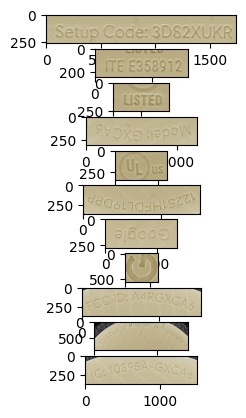

In [16]:
plt.figure()

fig,ax = plt.subplots(len(rois),1)
for i in range(len(rois)):
    ax[i].imshow(rois[i])

<Figure size 640x480 with 0 Axes>

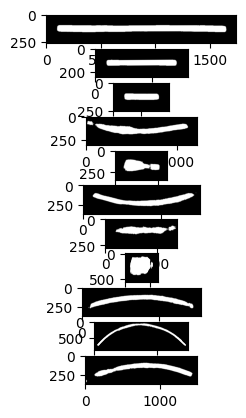

In [17]:
plt.figure()

fig,ax = plt.subplots(len(masks),1)
for i in range(len(masks)):
    ax[i].imshow(masks[i])

# 2.fit-in circle

(902, 2999)


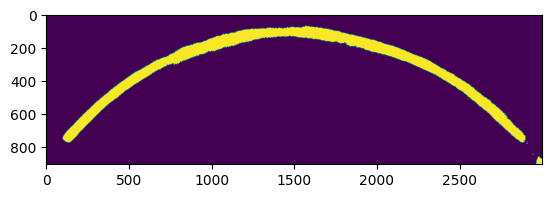

In [18]:
idx=-2
mask = masks[idx]
mask = cv2.cvtColor(mask,cv2.COLOR_BGR2GRAY)
h,w = mask.shape
print(mask.shape)
plt.imshow(mask)

In [19]:
curve = []
for i in range(w):
    v_line = mask[:,i:i+1]
    pos = cv2.findNonZero(v_line)
    if pos is not None:
        curve.append((pos[0][0][1],i))

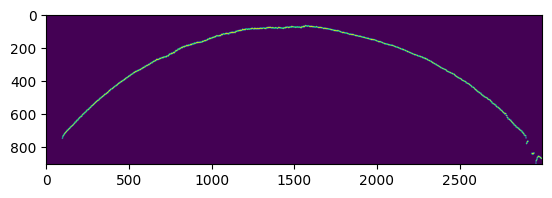

In [20]:
blank = np.zeros_like(mask)
for point in curve:
    cv2.circle(blank,(point[1], point[0]), 3, (255,255,255), -1)
plt.imshow(blank)

In [21]:
xc, yc, r, sigma = taubinSVD(curve)
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

xc=1888, yc=1491, r=1809, sigma=5.567289423341359


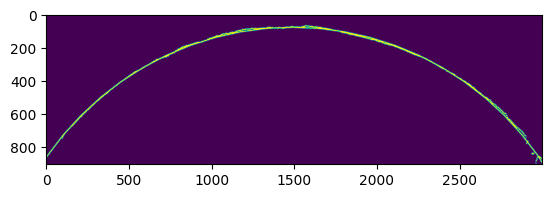

In [22]:
cv2.circle(blank, (int(yc),int(xc)), int(r), (255), 6)
plt.imshow(blank)

# 3.wrap roi

In [23]:
r = int(r)

(3618, 3618, 3)


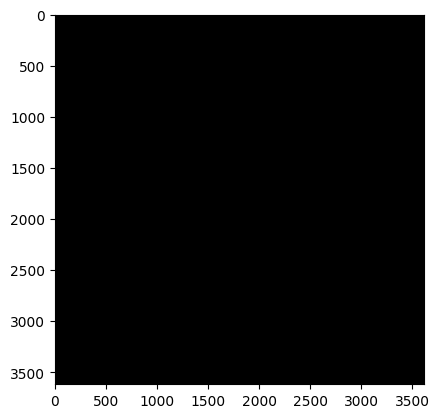

In [24]:
blank = np.zeros((r*2,r*2,3))
mask = np.zeros((r*2,r*2,3))
blank = blank.astype(np.uint8)
print(blank.shape)
plt.imshow(blank)

In [25]:
x = int(r - w/2)
y = 0

In [26]:
x2 = x+w
y2 = h

In [27]:
blank[y:y2,x:x2].shape

(902, 2999, 3)

Text(0.5, 1.0, 'color')

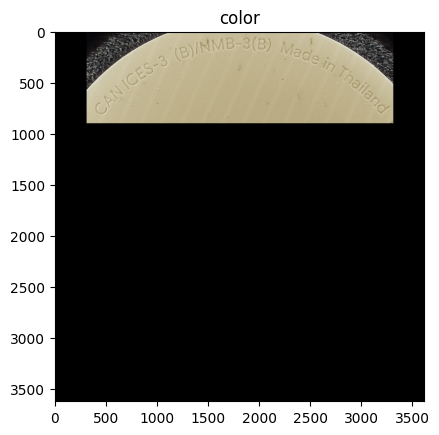

In [28]:
blank[y:y2,x:x2]= rois[idx]
plt.imshow(blank)
plt.title("color")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'mask')

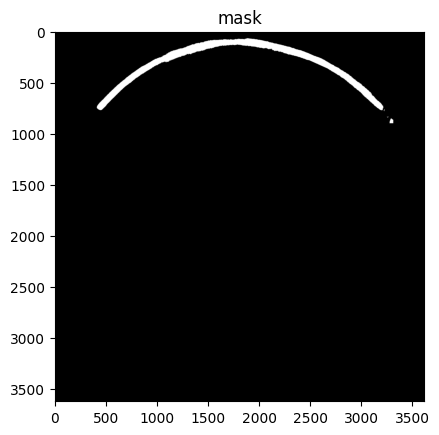

In [29]:
mask[y:y2,x:x2]= masks[idx]
plt.imshow(mask)
plt.title("mask")

Text(0.5, 1.0, 'color')

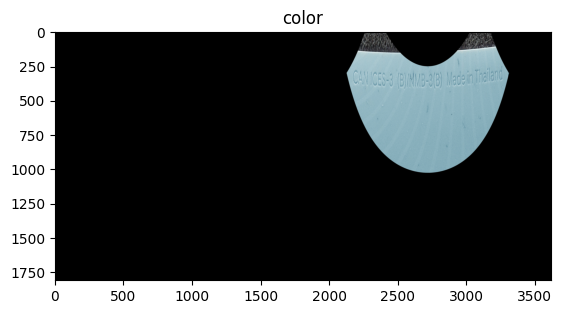

In [30]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_img = cv2.warpPolar(blank,(r,r*2),(r,r),r+300,flags) # w,h
out = polar_img.transpose(1,0,2)[::-1]
plt.imshow(cv2.cvtColor(out,cv2.COLOR_BGR2RGB))
plt.title('color')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'mask')

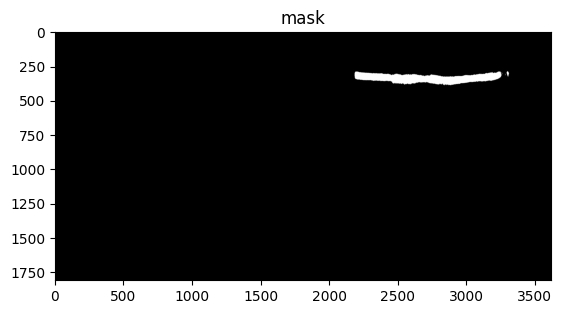

In [31]:
flags = cv2.INTER_CUBIC + cv2.WARP_FILL_OUTLIERS + cv2.WARP_POLAR_LINEAR
polar_mask = cv2.warpPolar(mask,(r,r*2),(r,r),r+300,flags) # w,h
out_m = polar_mask.transpose(1,0,2)[::-1]
plt.imshow(out_m)
plt.title('mask')

In [32]:
# convert to np.uint8
out_m = out_m.astype(np.uint8)
print(f"max value: {out_m.max()}")
print(f"min value: {out_m.min()}")

max value: 255
min value: 0


In [33]:
gray = cv2.cvtColor(out_m, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, 0)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(len(contours))

238


In [34]:
areas = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    areas.append(area)
    
cnt_max = contours[np.argmax(areas)]

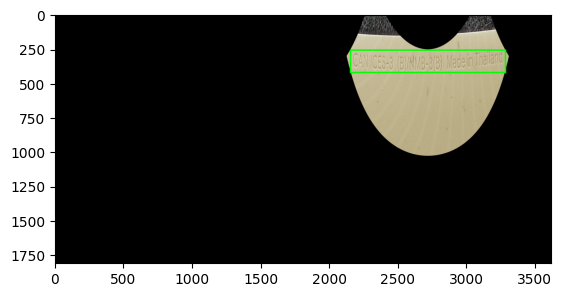

In [35]:
padding = 30
img = out.copy()
xr,yr,w,h = cv2.boundingRect(cnt_max)
cv2.rectangle(img,(xr-padding,yr-padding),(xr+w+padding,yr+h+padding),(0,255,0),10)
plt.imshow(img)

In [36]:
x0=xr-padding
y0=yr-padding
x1=xr+w+padding
y1=yr+h+padding
print(f"x0={x0},y0={y0},x1={x1},y1={y1}")

x0=2151,y0=262,x1=3279,y1=425


(1809, 3618, 3)


True

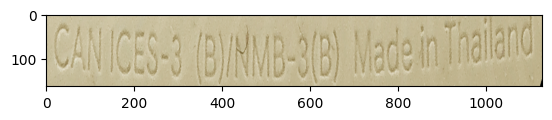

In [37]:
out2 = out[y0:y1,x0:x1]
print(out.shape)
plt.imshow(out2)
cv2.imwrite("out.jpg",out2)

In [38]:
lab= cv2.cvtColor(out2, cv2.COLOR_BGR2LAB)
l_channel, a, b = cv2.split(lab)

# Applying CLAHE to L-channel
# feel free to try different values for the limit and grid size:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(l_channel)

# merge the CLAHE enhanced L-channel with the a and b channel
limg = cv2.merge((cl,a,b))

# Converting image from LAB Color model to BGR color spcae
out2 = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

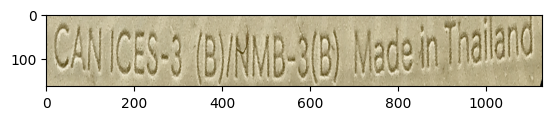

In [39]:
plt.imshow(out2)

# 4.Text recognition

In [184]:
!pwd

/home/greystone/locchuong/ocr-exp


In [185]:
!git clone https://github.com/PaddlePaddle/PaddleOCR.git

Cloning into 'PaddleOCR'...
remote: Enumerating objects: 45219, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 45219 (delta 9), reused 20 (delta 5), pack-reused 45193
Receiving objects: 100% (45219/45219), 338.36 MiB | 8.08 MiB/s, done.
Resolving deltas: 100% (31923/31923), done.


In [187]:
%cd PaddleOCR
!ls

/home/greystone/locchuong/ocr-exp/PaddleOCR
 applications   MANIFEST.in    requirements.txt
 benchmark      paddleocr.py   setup.py
 configs        ppocr	       StyleText
 deploy         PPOCRLabel     test_tipc
 doc	        ppstructure    tools
 __init__.py    README_ch.md   train.sh
 LICENSE        README.md     'Unconfirmed 970653.crdownload'


In [188]:
!pip install -r requirements.txt

  Using cached Polygon3-3.0.9.1-cp38-cp38-linux_x86_64.whl


In [190]:
!wget -P ./pretrain_models/ https://paddleocr.bj.bcebos.com/dygraph_v2.1/rec/rec_r31_sar_train.tar

--2023-01-03 12:46:29--  https://paddleocr.bj.bcebos.com/dygraph_v2.1/rec/rec_r31_sar_train.tar
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.46.61, 2409:8c04:1001:1002:0:ff:b001:368a
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.46.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 667349822 (636M) [application/x-tar]
Saving to: ‘./pretrain_models/rec_r31_sar_train.tar’

rec_r31_sar_train.t 100%[===================>] 636.43M  2.28MB/s    in 4m 25s  

2023-01-03 12:50:54 (2.40 MB/s) - ‘./pretrain_models/rec_r31_sar_train.tar’ saved [667349822/667349822]



In [191]:
%cd pretrain_models
!tar -xf rec_r31_sar_train.tar && rm -rf rec_r31_sar_train.tar
%cd ..

/home/greystone/locchuong/ocr-exp/PaddleOCR/pretrain_models


In [207]:
# Predict English results
!python3 tools/infer_rec.py -c configs/rec/PP-OCRv3/en_PP-OCRv3_rec.yml\
                            -o Global.pretrained_model=./pretrain_models/rec_r31_sar_train/best_accuracy.pdparams\
                            Global.infer_img=out.jpg\
                            Global.use_gpu=False

[2023/01/03 13:01:43] ppocr INFO: Architecture : 
[2023/01/03 13:01:43] ppocr INFO:     Backbone : 
[2023/01/03 13:01:43] ppocr INFO:         last_conv_stride : [1, 2]
[2023/01/03 13:01:43] ppocr INFO:         last_pool_type : avg
[2023/01/03 13:01:43] ppocr INFO:         name : MobileNetV1Enhance
[2023/01/03 13:01:43] ppocr INFO:         scale : 0.5
[2023/01/03 13:01:43] ppocr INFO:     Head : 
[2023/01/03 13:01:43] ppocr INFO:         head_list : 
[2023/01/03 13:01:43] ppocr INFO:             CTCHead : 
[2023/01/03 13:01:43] ppocr INFO:                 Head : 
[2023/01/03 13:01:43] ppocr INFO:                     fc_decay : 1e-05
[2023/01/03 13:01:43] ppocr INFO:                 Neck : 
[2023/01/03 13:01:43] ppocr INFO:                     depth : 2
[2023/01/03 13:01:43] ppocr INFO:                     dims : 64
[2023/01/03 13:01:43] ppocr INFO:                     hidden_dims : 120
[2023/01/03 13:01:43] ppocr INFO:                     name : svtr
[2023/01/03 13:01:43] ppocr INFO:   

[2023/01/03 13:01:44] ppocr INFO: 	 result: f(b	0.013241848908364773
[2023/01/03 13:01:44] ppocr INFO: success!


In [206]:
!cat output/rec/predicts_ppocrv3_en.txt

doc/imgs_words/en/word_2.png	X6	0.012808753177523613


# references

[PaddleOCR](https://github.com/PaddlePaddle/PaddleOCR/tree/release/2.6/doc/doc_en)

[RapidOCR](https://github.com/RapidAI/RapidOCR)

[openvino-paddlepaddle-demo](https://github.com/raymondlo84/openvino-paddlepaddle-demo)

[Interactive Tutorials (Python) openvino](https://docs.openvino.ai/latest/tutorials.html#doxid-tutorials)

[openvino-paddle](https://docs.openvino.ai/latest/openvino_docs_MO_DG_prepare_model_convert_model_Convert_Model_From_Paddle.html#)

[mmocr-guide](https://analyticsindiamag.com/a-guide-to-text-detection-and-recognition-using-mmocr/)

[mmocr](https://github.com/open-mmlab/mmocr)

[opencv-text-recognition](https://docs.opencv.org/4.x/d4/d43/tutorial_dnn_text_spotting.html)

[ocr-opencv-dnn](https://github.com/hpc203/ocr-opencv-dnn)

[deep-text-recognition-benchmark](https://github.com/clovaai/deep-text-recognition-benchmark)


[AdelaiDet](https://github.com/aim-uofa/AdelaiDet)


[adaptive-bezier-curve-network](https://www.kaggle.com/code/ipythonx/scene-text-spotting-adaptive-bezier-curve-network)